In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")

data

,time,latitude,longitude,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,2023-12-01,20.00,87.00,0.426811,-0.243200,0.038144,0.067167,0.000742,0.275052,0.039848,1.553997,211.99715,8.096696,31.763088,32.935463,27.544558,-9.283912e-06
1,2023-12-01,20.00,87.25,0.239383,-0.243972,0.098296,0.049014,0.000515,0.033682,0.075718,1.475152,207.69382,8.076305,31.978865,35.154820,27.640587,-4.772343e-09
2,2023-12-01,20.00,87.50,0.241742,-0.299730,0.205186,0.050251,0.000510,0.033237,0.075322,1.489284,207.43205,8.069997,31.241436,35.645664,27.237083,-4.544436e-07
3,2023-12-01,20.00,87.75,0.249776,-0.326079,0.192377,0.051030,0.000518,0.030686,0.083742,1.517359,206.83958,8.062381,32.552390,36.320885,27.821306,-3.646835e-06
4,2023-12-01,20.00,88.00,0.290600,-0.292960,0.164024,0.055139,0.000530,0.039709,0.096499,1.574215,206.07166,8.049930,33.392956,37.367664,28.283844,7.304160e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105904,2026-02-28,21.75,91.00,2.647063,0.057355,0.005189,0.197370,0.005230,15.320981,0.004378,12.087233,271.25156,8.157561,22.847067,28.096190,25.584400,-2.182290e-07
105905,2026-02-28,22.00,90.50,2.261087,0.021794,0.004798,0.181158,0.007977,9.132027,0.004292,7.969160,271.40800,8.107493,23.564825,26.976948,25.437767,-6.593571e-08
105906,2026-02-28,22.00,90.75,2.777321,0.023219,0.014129,0.213573,0.007051,13.064166,0.004646,12.401380,284.51260,8.129527,22.599352,26.893286,25.329893,-5.047739e-07
105907,2026-02-28,22.25,91.00,2.796277,-0.113082,-0.042643,0.208888,0.009179,30.923326,0.005974,14.192197,329.25305,8.296883,10.635326,18.745949,24.613987,1.122739e-07


In [3]:
# Create a version WITHOUT time/lat/lon ONLY for plotting & EDA
data_no_coords = data.drop(['time', 'latitude', 'longitude'], axis=1)

data_no_coords

,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,0.426811,-0.243200,0.038144,0.067167,0.000742,0.275052,0.039848,1.553997,211.99715,8.096696,31.763088,32.935463,27.544558,-9.283912e-06
1,0.239383,-0.243972,0.098296,0.049014,0.000515,0.033682,0.075718,1.475152,207.69382,8.076305,31.978865,35.154820,27.640587,-4.772343e-09
2,0.241742,-0.299730,0.205186,0.050251,0.000510,0.033237,0.075322,1.489284,207.43205,8.069997,31.241436,35.645664,27.237083,-4.544436e-07
3,0.249776,-0.326079,0.192377,0.051030,0.000518,0.030686,0.083742,1.517359,206.83958,8.062381,32.552390,36.320885,27.821306,-3.646835e-06
4,0.290600,-0.292960,0.164024,0.055139,0.000530,0.039709,0.096499,1.574215,206.07166,8.049930,33.392956,37.367664,28.283844,7.304160e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105904,2.647063,0.057355,0.005189,0.197370,0.005230,15.320981,0.004378,12.087233,271.25156,8.157561,22.847067,28.096190,25.584400,-2.182290e-07
105905,2.261087,0.021794,0.004798,0.181158,0.007977,9.132027,0.004292,7.969160,271.40800,8.107493,23.564825,26.976948,25.437767,-6.593571e-08
105906,2.777321,0.023219,0.014129,0.213573,0.007051,13.064166,0.004646,12.401380,284.51260,8.129527,22.599352,26.893286,25.329893,-5.047739e-07
105907,2.796277,-0.113082,-0.042643,0.208888,0.009179,30.923326,0.005974,14.192197,329.25305,8.296883,10.635326,18.745949,24.613987,1.122739e-07


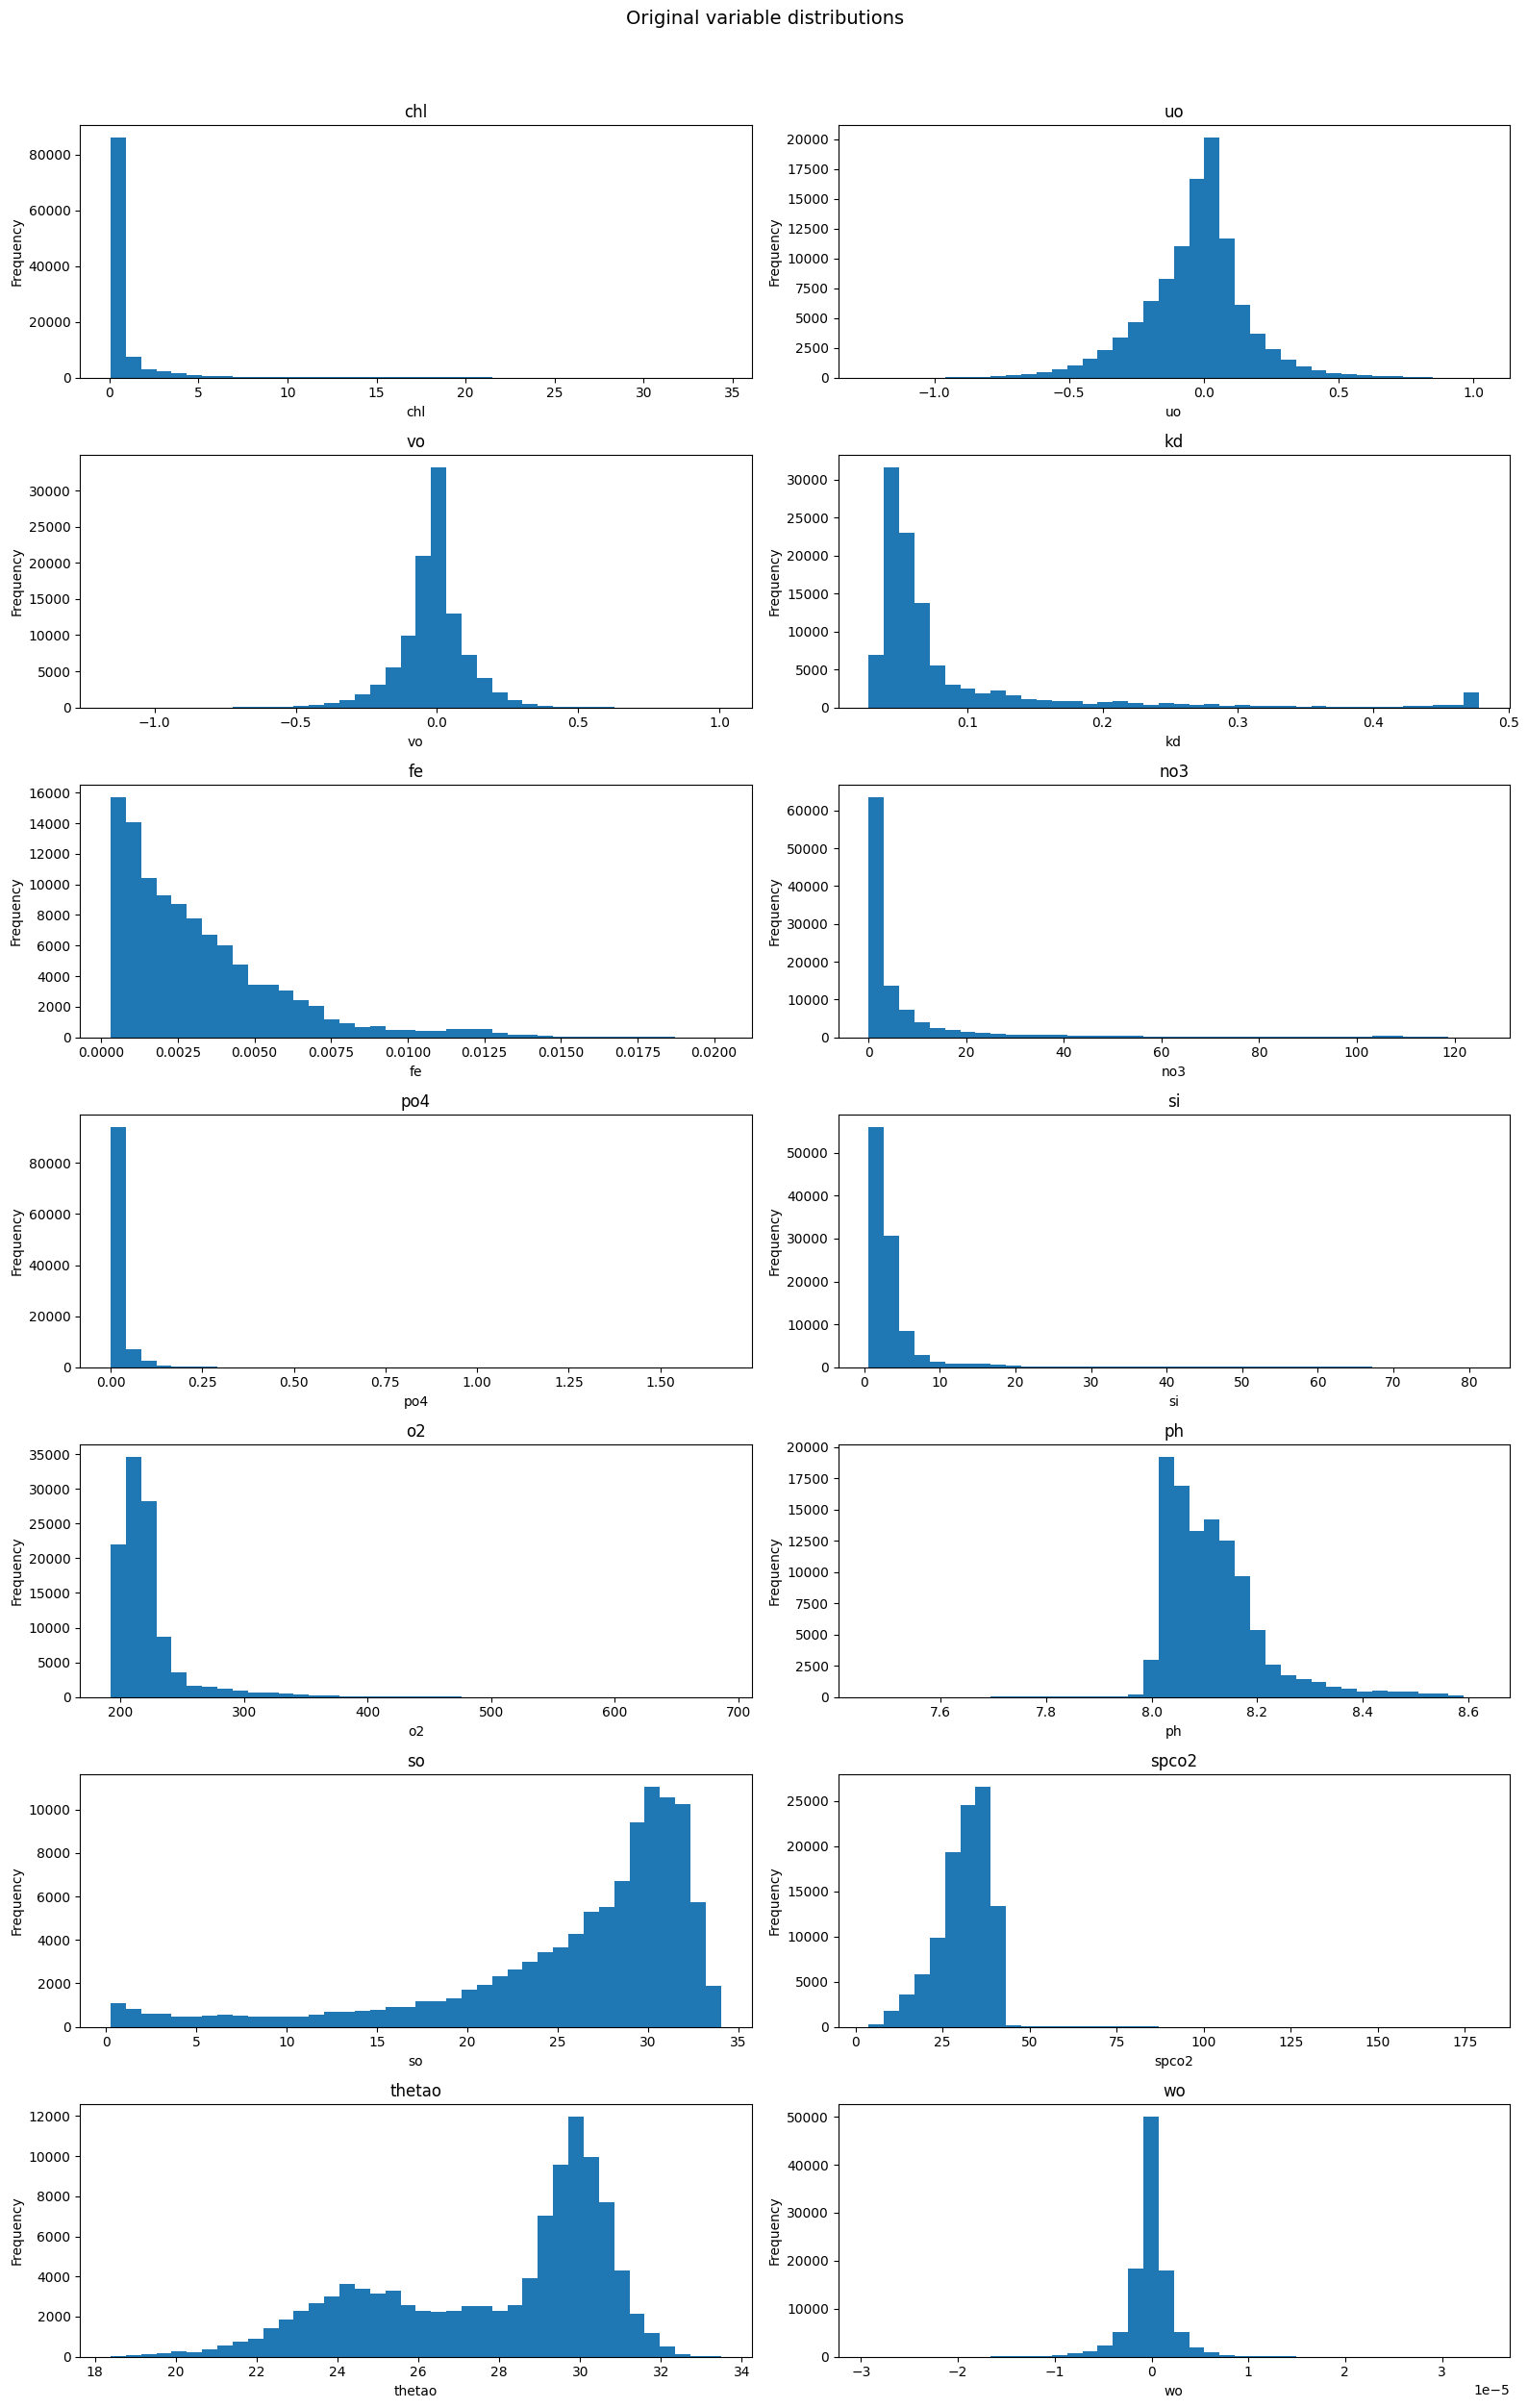

In [4]:
n = data_no_coords.shape[1]
cols_per_row = 2
rows = (n + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(16, rows * 3.5))
for i, col in enumerate(data_no_coords.columns):
    ax = plt.subplot(rows, cols_per_row, i + 1)
    # coerce to numeric for plotting safety
    vals = pd.to_numeric(data_no_coords[col], errors="coerce").dropna()
    if vals.size == 0:
        ax.text(0.5, 0.5, f"No numeric data\nfor {col}", ha="center", va="center")
        ax.set_title(col)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ax.hist(vals, bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Original variable distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

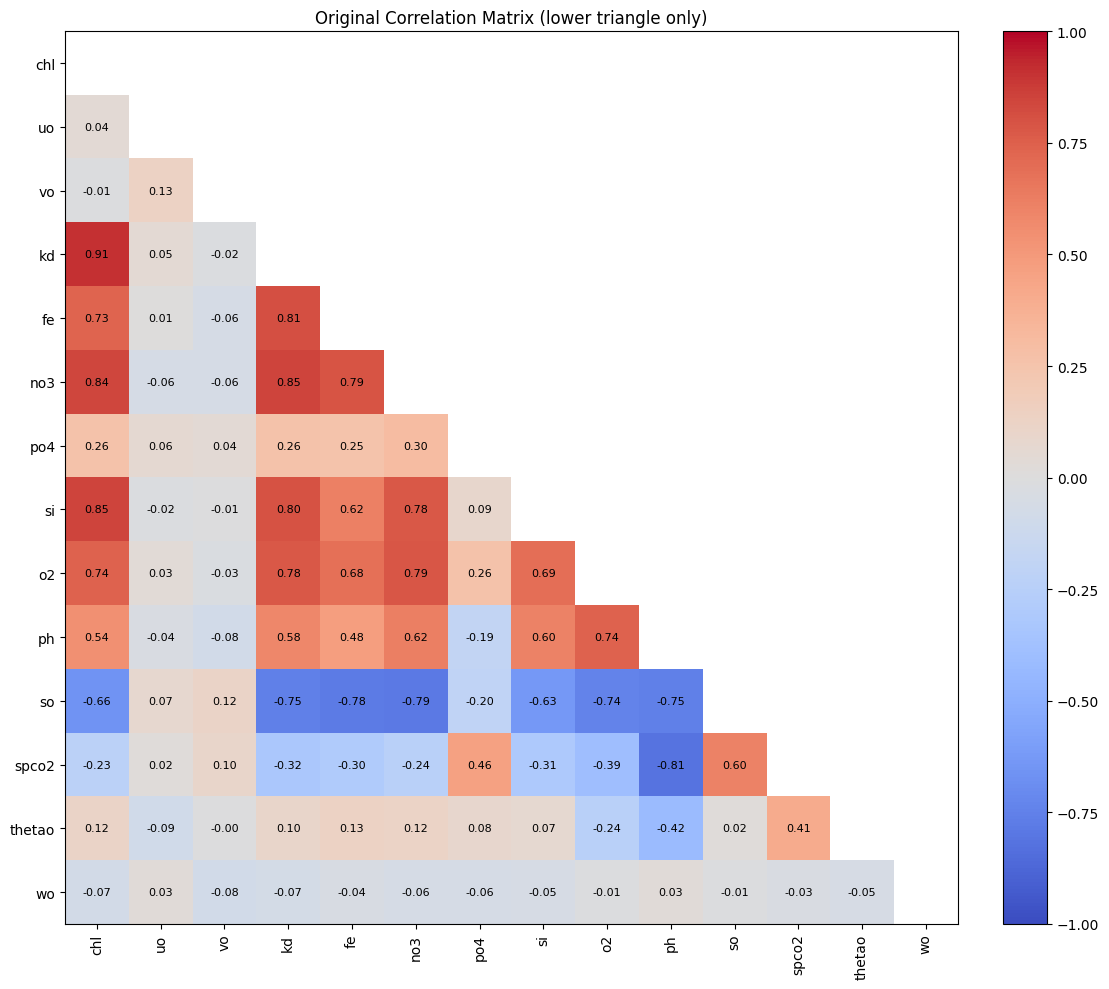

In [5]:
corr = data_no_coords.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

fig, ax = plt.subplots(figsize=(12, 10))
# Masked values are drawn as white
im = ax.imshow(corr.where(~mask), cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Show correlation coefficients in the lower triangle only
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i > j:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.title("Original Correlation Matrix (lower triangle only)")
plt.tight_layout()
plt.show()

In [6]:
# Apply np.log1p (safe log) transform to the selected columns
log1p_cols = ["kd", "fe", "no3", "po4", "si", "o2", "spco2"]

# Create a copy of the data to preserve the original
data_log1p = data.copy()

for col in log1p_cols:
    # Only apply transformation if the column exists (extra safety)
    if col in data_log1p.columns:
        data_log1p[col] = np.log1p(pd.to_numeric(data_log1p[col], errors="coerce"))

data_log1p

,time,latitude,longitude,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,2023-12-01,20.00,87.00,0.426811,-0.243200,0.038144,0.065008,0.000742,0.242987,0.039075,0.937660,5.361279,8.096696,31.763088,3.524461,27.544558,-9.283912e-06
1,2023-12-01,20.00,87.25,0.239383,-0.243972,0.098296,0.047851,0.000514,0.033127,0.072988,0.906302,5.340868,8.076305,31.978865,3.587810,27.640587,-4.772343e-09
2,2023-12-01,20.00,87.50,0.241742,-0.299730,0.205186,0.049029,0.000510,0.032696,0.072620,0.911995,5.339613,8.069997,31.241436,3.601295,27.237083,-4.544436e-07
3,2023-12-01,20.00,87.75,0.249776,-0.326079,0.192377,0.049771,0.000518,0.030225,0.080420,0.923210,5.336767,8.062381,32.552390,3.619553,27.821306,-3.646835e-06
4,2023-12-01,20.00,88.00,0.290600,-0.292960,0.164024,0.053672,0.000530,0.038941,0.092122,0.945545,5.333065,8.049930,33.392956,3.647215,28.283844,7.304160e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105904,2026-02-28,21.75,91.00,2.647063,0.057355,0.005189,0.180127,0.005217,2.792451,0.004368,2.571637,5.606726,8.157561,22.847067,3.370607,25.584400,-2.182290e-07
105905,2026-02-28,22.00,90.50,2.261087,0.021794,0.004798,0.166496,0.007945,2.315701,0.004282,2.193792,5.607301,8.107493,23.564825,3.331381,25.437767,-6.593571e-08
105906,2026-02-28,22.00,90.75,2.777321,0.023219,0.014129,0.193569,0.007027,2.643630,0.004635,2.595358,5.654286,8.129527,22.599352,3.328386,25.329893,-5.047739e-07
105907,2026-02-28,22.25,91.00,2.796277,-0.113082,-0.042643,0.189701,0.009137,3.463337,0.005957,2.720782,5.799859,8.296883,10.635326,2.982948,24.613987,1.122739e-07


In [7]:
# Create a version WITHOUT time/lat/lon ONLY for plotting & EDA
data_log1p_no_coords = data_log1p.drop(['time', 'latitude', 'longitude'], axis=1)

data_log1p_no_coords

,chl,uo,vo,kd,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,0.426811,-0.243200,0.038144,0.065008,0.000742,0.242987,0.039075,0.937660,5.361279,8.096696,31.763088,3.524461,27.544558,-9.283912e-06
1,0.239383,-0.243972,0.098296,0.047851,0.000514,0.033127,0.072988,0.906302,5.340868,8.076305,31.978865,3.587810,27.640587,-4.772343e-09
2,0.241742,-0.299730,0.205186,0.049029,0.000510,0.032696,0.072620,0.911995,5.339613,8.069997,31.241436,3.601295,27.237083,-4.544436e-07
3,0.249776,-0.326079,0.192377,0.049771,0.000518,0.030225,0.080420,0.923210,5.336767,8.062381,32.552390,3.619553,27.821306,-3.646835e-06
4,0.290600,-0.292960,0.164024,0.053672,0.000530,0.038941,0.092122,0.945545,5.333065,8.049930,33.392956,3.647215,28.283844,7.304160e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105904,2.647063,0.057355,0.005189,0.180127,0.005217,2.792451,0.004368,2.571637,5.606726,8.157561,22.847067,3.370607,25.584400,-2.182290e-07
105905,2.261087,0.021794,0.004798,0.166496,0.007945,2.315701,0.004282,2.193792,5.607301,8.107493,23.564825,3.331381,25.437767,-6.593571e-08
105906,2.777321,0.023219,0.014129,0.193569,0.007027,2.643630,0.004635,2.595358,5.654286,8.129527,22.599352,3.328386,25.329893,-5.047739e-07
105907,2.796277,-0.113082,-0.042643,0.189701,0.009137,3.463337,0.005957,2.720782,5.799859,8.296883,10.635326,2.982948,24.613987,1.122739e-07


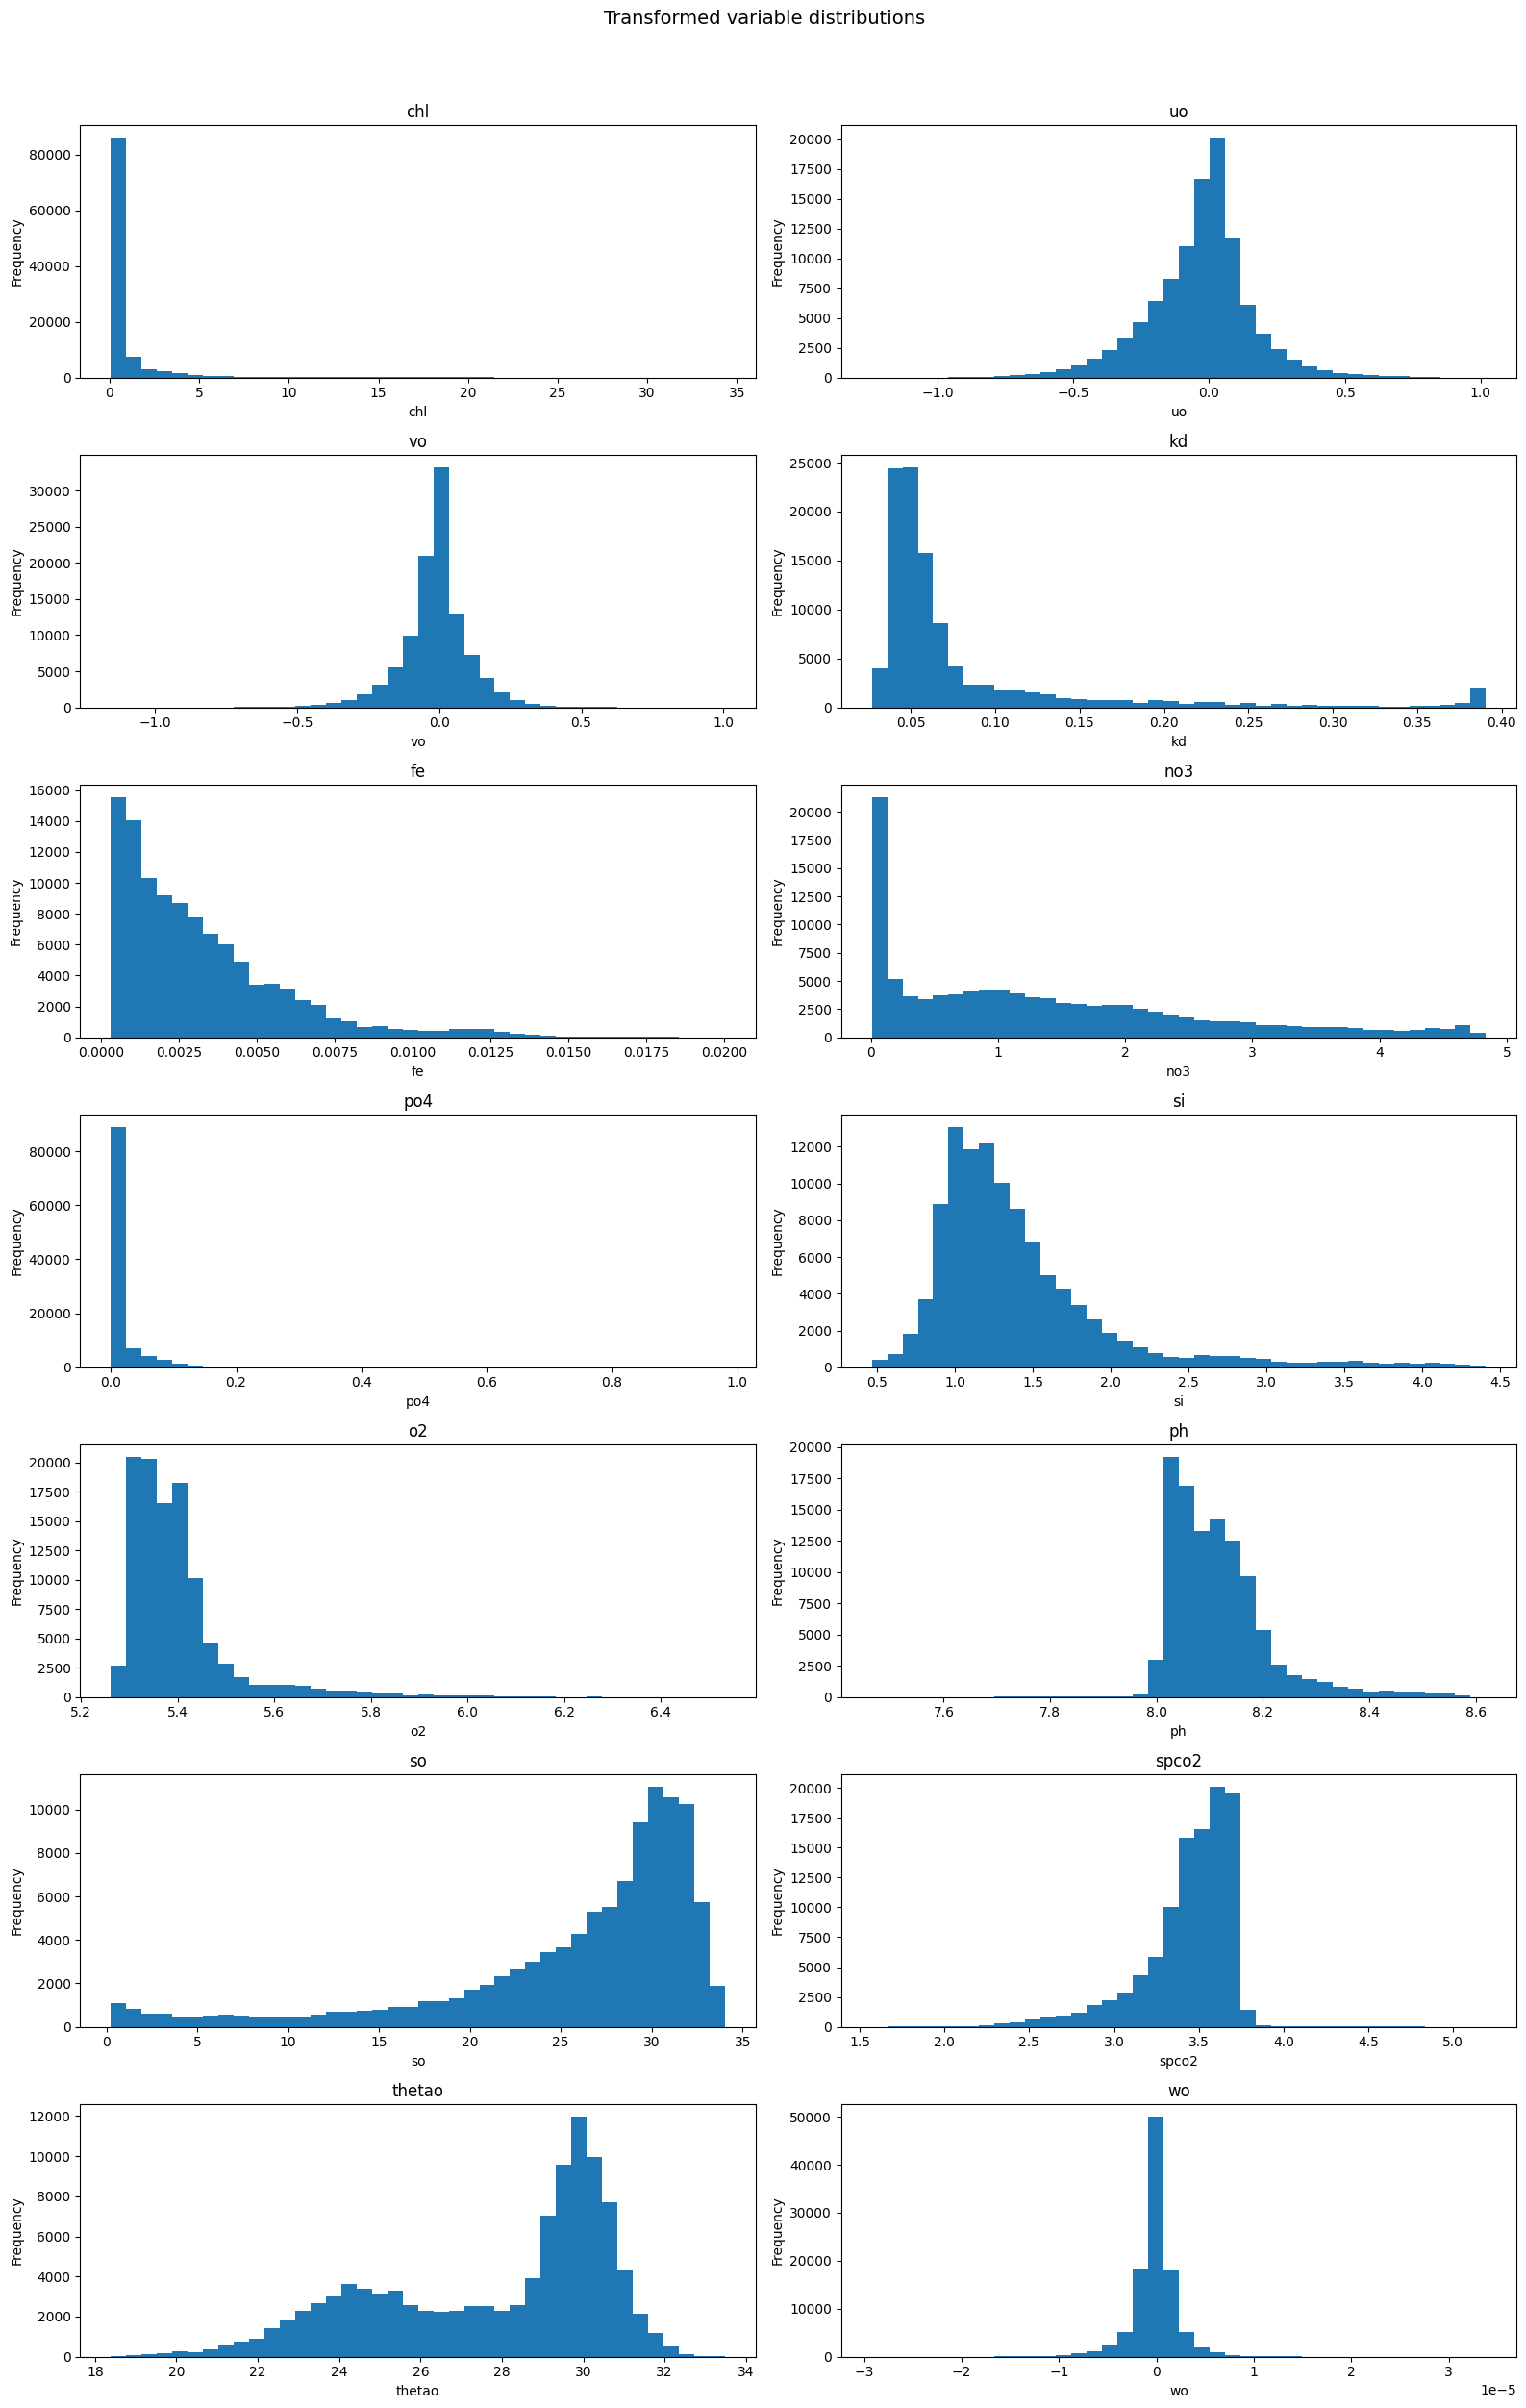

In [8]:
n = data_log1p_no_coords.shape[1]
cols_per_row = 2
rows = (n + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(16, rows * 3.5))
for i, col in enumerate(data_log1p_no_coords.columns):
    ax = plt.subplot(rows, cols_per_row, i + 1)
    # coerce to numeric for plotting safety
    vals = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").dropna()
    if vals.size == 0:
        ax.text(0.5, 0.5, f"No numeric data\nfor {col}", ha="center", va="center")
        ax.set_title(col)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ax.hist(vals, bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Transformed variable distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

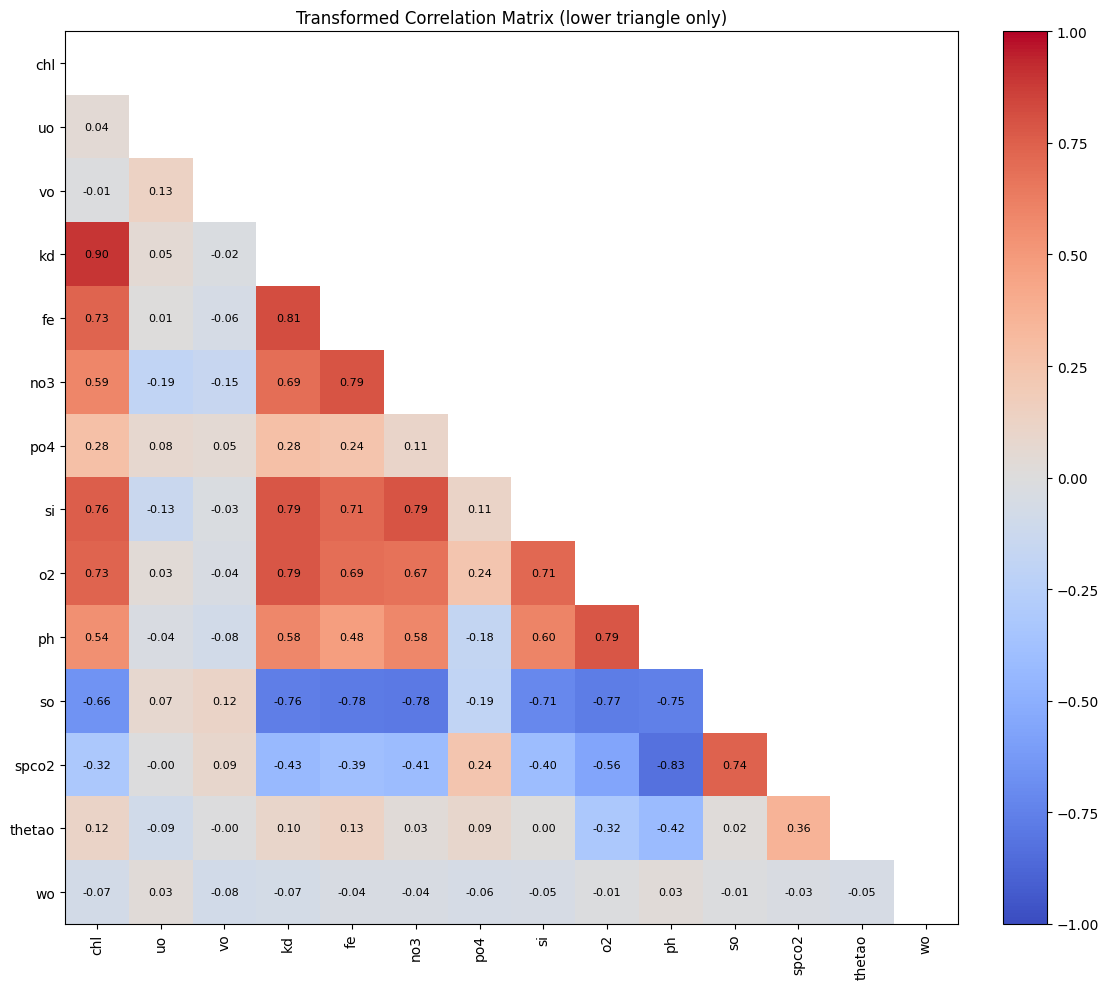

In [9]:
corr = data_log1p_no_coords.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

fig, ax = plt.subplots(figsize=(12, 10))
# Masked values are drawn as white
im = ax.imshow(corr.where(~mask), cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Show correlation coefficients in the lower triangle only
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i > j:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.title("Transformed Correlation Matrix (lower triangle only)")
plt.tight_layout()
plt.show()

In [10]:
data_log1p.to_csv("data_normalized.csv", index=False)

In [11]:
from sklearn.metrics import r2_score

target = "chl"
results = []
feature_cols = [col for col in data_log1p_no_coords.columns if col != target]

n_features = len(feature_cols)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

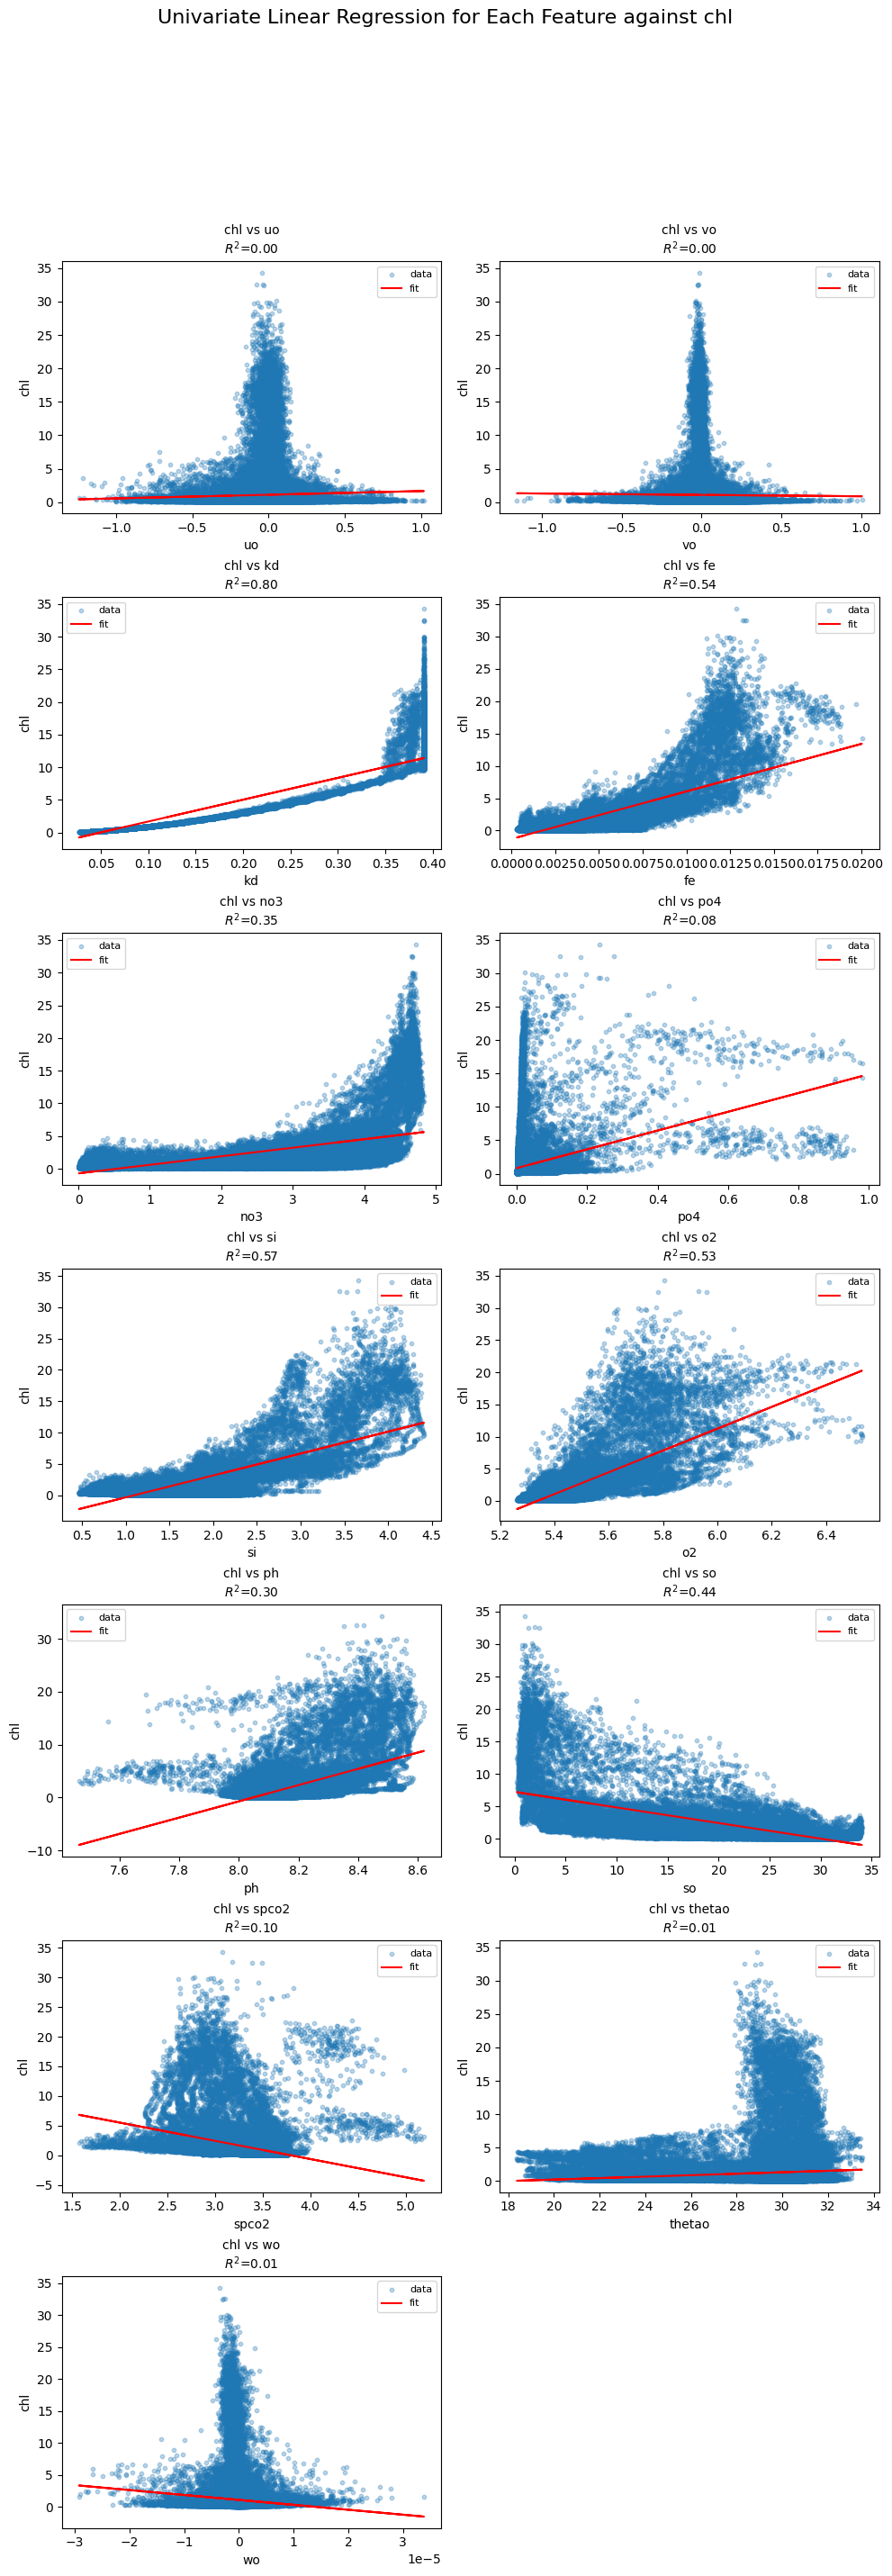

,feature,coef,intercept,r2
0,kd,33.431619,-1.651771,0.804873
1,si,3.496003,-3.847563,0.571588
2,fe,734.541939,-1.286674,0.535176
3,o2,16.938107,-90.407834,0.534160
4,so,-0.240019,7.260078,0.437935
5,no3,1.304583,-0.689805,0.350827
6,ph,15.382104,-123.764575,0.295374
7,spco2,-3.072115,11.651619,0.102324
8,po4,14.029938,0.849653,0.076776
9,thetao,0.109551,-1.967784,0.013416


In [12]:
from sklearn.linear_model import LinearRegression

results = []

# Perform regression, record results, and store data for plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    X = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").values.reshape(-1, 1)
    y = pd.to_numeric(data_log1p_no_coords[target], errors="coerce").values
    mask = (~pd.isna(X).flatten()) & (~pd.isna(y))
    X_clean = X[mask].reshape(-1, 1)
    y_clean = y[mask]
    if X_clean.shape[0] == 0:
        continue
    lr = LinearRegression()
    lr.fit(X_clean, y_clean)
    y_pred = lr.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    coef = lr.coef_[0]
    intercept = lr.intercept_
    results.append({
        "feature": col,
        "coef": coef,
        "intercept": intercept,
        "r2": r2
    })
    # Plot regression scatter with line
    ax = axes[idx]
    ax.scatter(X_clean, y_clean, alpha=0.3, label='data', s=10)
    ax.plot(X_clean, y_pred, color='red', label='fit')
    ax.set_title(f"{target} vs {col}\n$R^2$={r2:.2f}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.legend(fontsize=8)

# Hide any unused subplots
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Univariate Linear Regression for Each Feature against chl", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()

# Sort results by absolute value of R^2
results_sorted = sorted(results, key=lambda d: abs(d["r2"]), reverse=True)

# Tabulate results
df_results = pd.DataFrame(results_sorted)
df_results

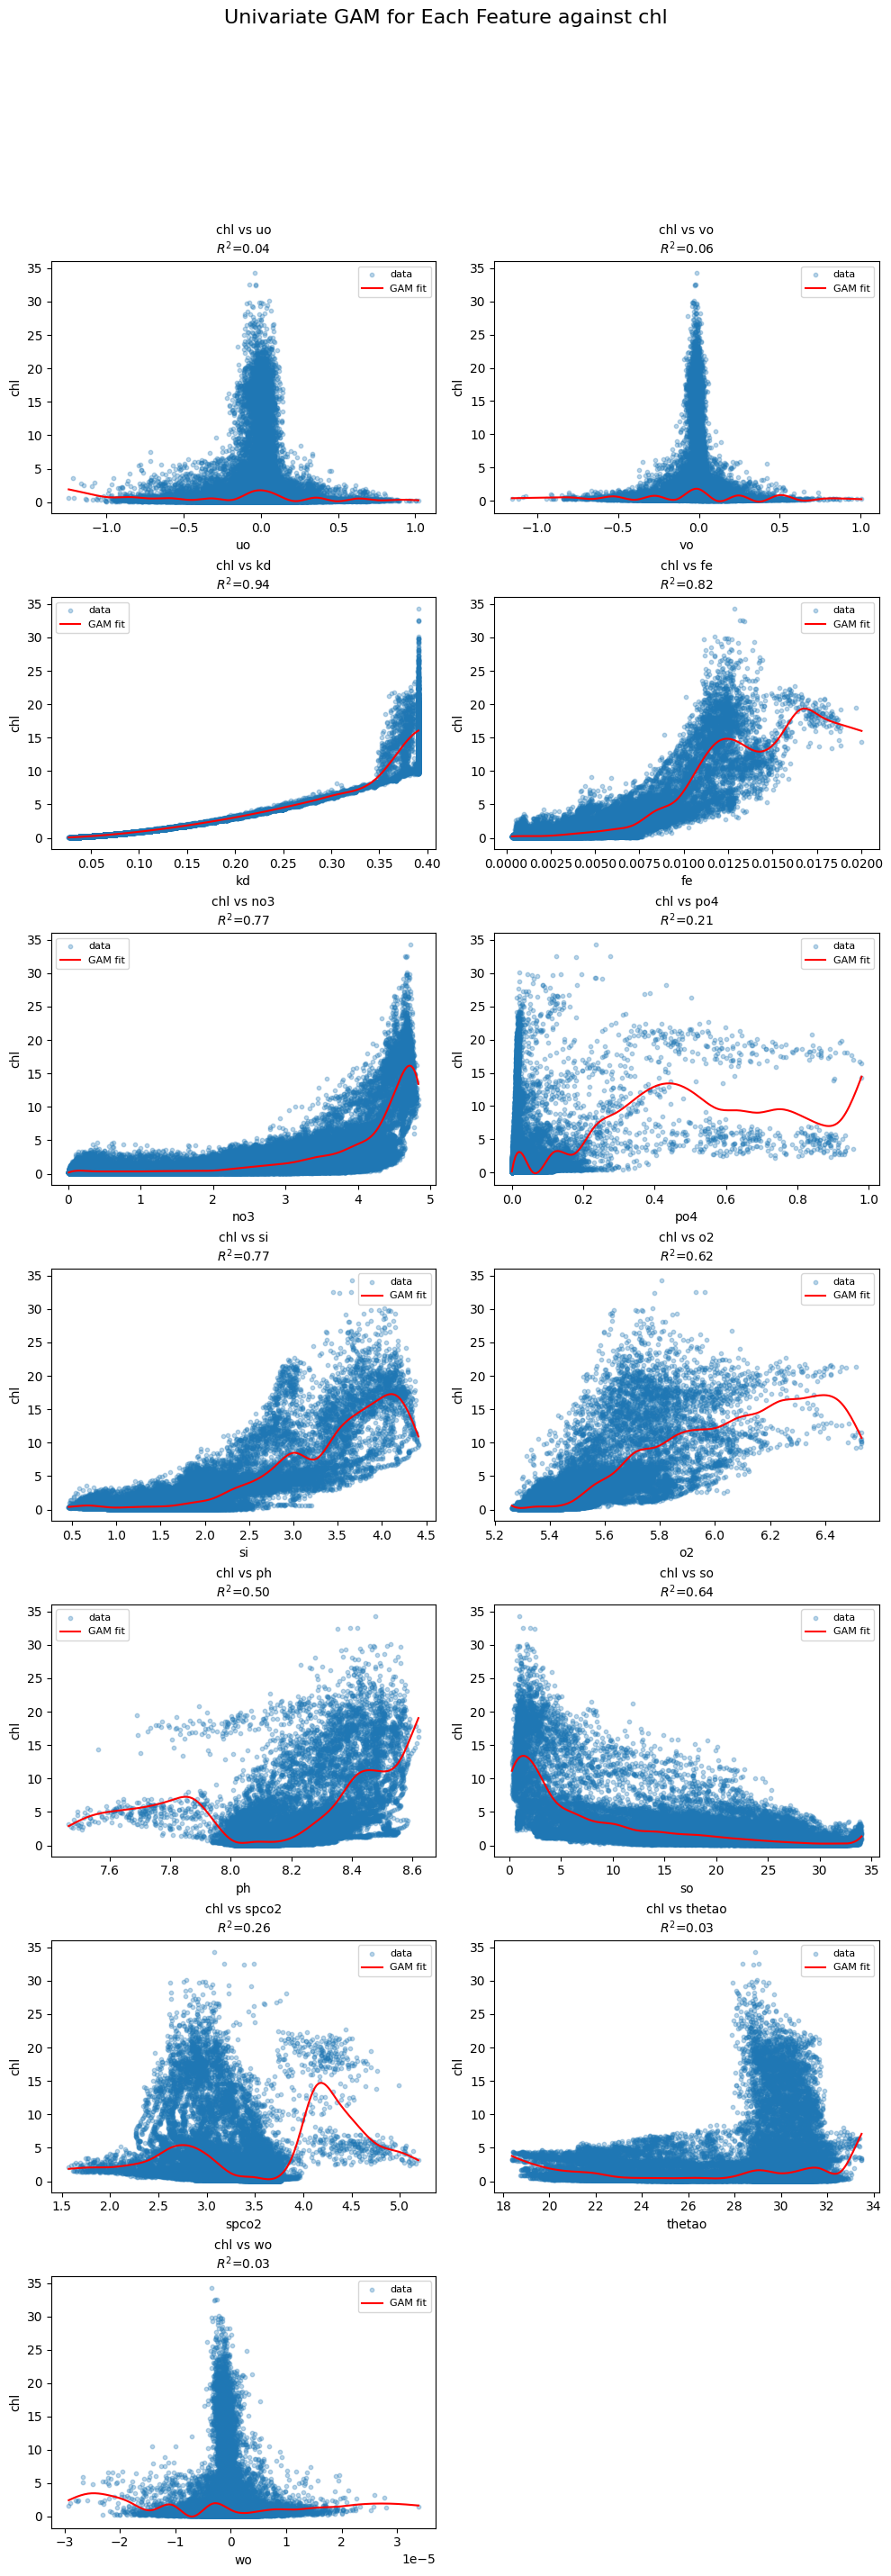

,feature,r2
0,kd,0.937621
1,fe,0.815852
2,si,0.773699
3,no3,0.768304
4,so,0.641379
5,o2,0.618946
6,ph,0.503398
7,spco2,0.261993
8,po4,0.209020
9,vo,0.056253


In [13]:
from pygam import LinearGAM, s

results = []

# Perform univariate GAM regression, record results, and store data for plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    X = pd.to_numeric(data_log1p_no_coords[col], errors="coerce").values.reshape(-1, 1)
    y = pd.to_numeric(data_log1p_no_coords[target], errors="coerce").values
    mask = (~pd.isna(X).flatten()) & (~pd.isna(y))
    X_clean = X[mask].reshape(-1, 1)
    y_clean = y[mask]
    if X_clean.shape[0] == 0:
        continue
    gam = LinearGAM(s(0))
    gam.fit(X_clean, y_clean)
    y_pred = gam.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    # For GAM, there is no coef/intercept like in linear regression, but show importance as explained variance
    results.append({
        "feature": col,
        "r2": r2
    })
    # Plot regression scatter with smooth GAM line
    ax = axes[idx]
    # Plot scatter data
    ax.scatter(X_clean, y_clean, alpha=0.3, label='data', s=10)
    # Plot smooth GAM prediction curve
    XX = np.linspace(X_clean.min(), X_clean.max(), 200).reshape(-1, 1)
    ax.plot(XX, gam.predict(XX), color='red', label='GAM fit')
    ax.set_title(f"{target} vs {col}\n$R^2$={r2:.2f}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.legend(fontsize=8)

# Hide any unused subplots
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Univariate GAM for Each Feature against chl", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()

# Sort results by absolute value of R^2
results_sorted = sorted(results, key=lambda d: abs(d["r2"]), reverse=True)

# Tabulate results
df_results = pd.DataFrame(results_sorted)
df_results